In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce GTX 1650


In [25]:
def corrupt_image(img):

    def add_noise(i):
        return np.clip(i + np.random.normal(0,20,i.shape),0,255).astype(np.uint8)

    def blur(i):
        return cv2.GaussianBlur(i,(5,5),0)

    def lowres(i):
        h,w = i.shape[:2]
        small = cv2.resize(i,(w//3,h//3))
        return cv2.resize(small,(w,h))

    return random.choice([add_noise, blur, lowres])(img)

In [26]:
class RAImageDataset(Dataset):

    def __init__(self, root_dir, img_size=224):

        self.paths = [os.path.join(root_dir,f) for f in os.listdir(root_dir)]

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size,img_size))
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        corrupted = corrupt_image(img.copy())

        clean = self.transform(img)
        corrupted = self.transform(corrupted)

        return corrupted, clean

In [27]:
DATA_PATH = r"D:\Image Recognition\data"

dataset = RAImageDataset(DATA_PATH)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

print("Dataset size:", len(dataset))

Dataset size: 3000


In [28]:
class Block(nn.Module):

    def __init__(self,a,b):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(a,b,3,1,1),
            nn.BatchNorm2d(b),
            nn.ReLU()
        )

    def forward(self,x):
        return self.net(x)


class ProcessingNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            Block(3,64),
            Block(64,64),

            nn.MaxPool2d(2),

            Block(64,128),
            Block(128,128),

            nn.Upsample(scale_factor=2),

            Block(128,64),

            nn.Conv2d(64,3,3,1,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [29]:
model = ProcessingNet().to(device)

model.load_state_dict(
    torch.load("baseline_model.pth", map_location=device)
)

print("Baseline model loaded")

Baseline model loaded


In [30]:
teacher = models.resnet101(
    weights=models.ResNet101_Weights.DEFAULT
)

teacher = teacher.to(device)
teacher.eval()

print("ResNet101 teacher loaded")

ResNet101 teacher loaded


In [31]:
normalize = transforms.Normalize(
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225]
)

In [32]:
image_loss_fn = nn.MSELoss()
class_loss_fn = nn.CrossEntropyLoss()

# optimizer = optim.Adam(model.parameters(), lr=1e-4)

# lambda_recog = 0.1

In [33]:
lambda_values = [0, 0.01, 0.1, 0.5, 1]

for lambda_recog in lambda_values:

    print(f"\n========== Training ResNet101 with λ = {lambda_recog} ==========\n")

    # Reset processing model
    model = ProcessingNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    

    for epoch in range(5):

        total_loss = 0
        pbar = tqdm(loader)

        for corrupted, clean in pbar:

            corrupted = corrupted.to(device)
            clean = clean.to(device)

            # ----- Forward -----
            restored = model(corrupted)

            # ----- Image Loss -----
            img_loss = image_loss_fn(restored, clean)

            # ----- Recognition Loss -----
            with torch.no_grad():
                teacher_pred = teacher(normalize(clean))
                labels = teacher_pred.argmax(dim=1)

            pred = teacher(normalize(restored))
            recog_loss = class_loss_fn(pred, labels)

            #  Combined Loss
            loss = img_loss + lambda_recog * recog_loss

            # ----- Backprop -----
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            pbar.set_postfix(
                total=loss.item(),
                img=img_loss.item(),
                cls=recog_loss.item(),
                lam=lambda_recog
            )

        print(f"Epoch {epoch+1} Loss: {total_loss/len(loader):.4f}")

    # Save model
    torch.save(model.state_dict(), f"RA_resnet101_lambda_{lambda_recog}.pth")

    print(f" Saved ResNet101 model for λ = {lambda_recog}")


========== Training ResNet101 with λ = 0 ==========



  0%|          | 0/375 [00:00<?, ?it/s]

100%|██████████| 375/375 [05:58<00:00,  1.04it/s, cls=1.08, img=0.00365, lam=0, total=0.00365] 


Epoch 1 Loss: 0.0067


100%|██████████| 375/375 [06:23<00:00,  1.02s/it, cls=1.29, img=0.00314, lam=0, total=0.00314] 


...

Epoch 3 Loss: 1.2560


100%|██████████| 375/375 [04:38<00:00,  1.35it/s, cls=0.797, img=0.0147, lam=1, total=0.812] 


Epoch 4 Loss: 1.1903


100%|██████████| 375/375 [04:35<00:00,  1.36it/s, cls=1.1, img=0.0147, lam=1, total=1.12]    

Epoch 5 Loss: 1.1421
 Saved ResNet101 model for λ = 1


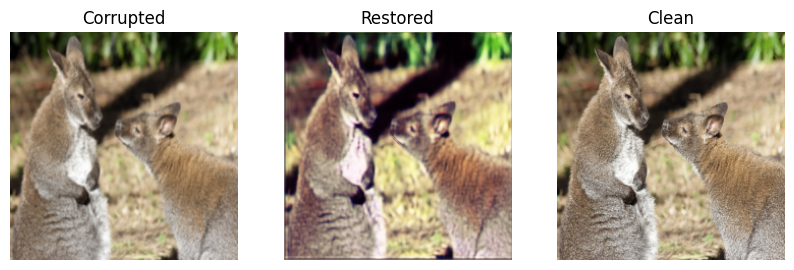

In [34]:
corrupted, clean = next(iter(loader))

corrupted = corrupted.to(device)

with torch.no_grad():
    restored = model(corrupted).cpu()

def show(img):
    img = img.permute(1,2,0).numpy()
    img = np.clip(img,0,1)
    plt.imshow(img)
    plt.axis("off")

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
show(corrupted[0].cpu())
plt.title("Corrupted")

plt.subplot(1,3,2)
show(restored[0])
plt.title("Restored")

plt.subplot(1,3,3)
show(clean[0])
plt.title("Clean")

plt.show() 